In [ ]:
!cp /content/drive/MyDrive/nutrivision_merged.zip /content

In [ ]:
import os
size = os.path.getsize('/content/nutrivision_merged.zip')
print(f"📦 Size: {size / (1024*1024):.1f} MB")

📦 Size: 1962.4 MB


In [ ]:
import zipfile
import os

zip_path = '/content/nutrivision_merged.zip'   # ← change if your zip is elsewhere
extract_to = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Unzipped successfully!")
path="/content/nutrivision_merged"
# Verify structure
for split in ['train', 'valid', 'test']:
    imgs = len(list(os.listdir(f"{path}/{split}/images")))
    lbls = len(list(os.listdir(f"{path}/{split}/labels")))
    print(f"  {split:6s} → {imgs} images, {lbls} labels")

✅ Unzipped successfully!
  train  → 34905 images, 34905 labels
  valid  → 2405 images, 2405 labels
  test   → 1875 images, 1875 labels


Found 500 images for 'sambar_satham'


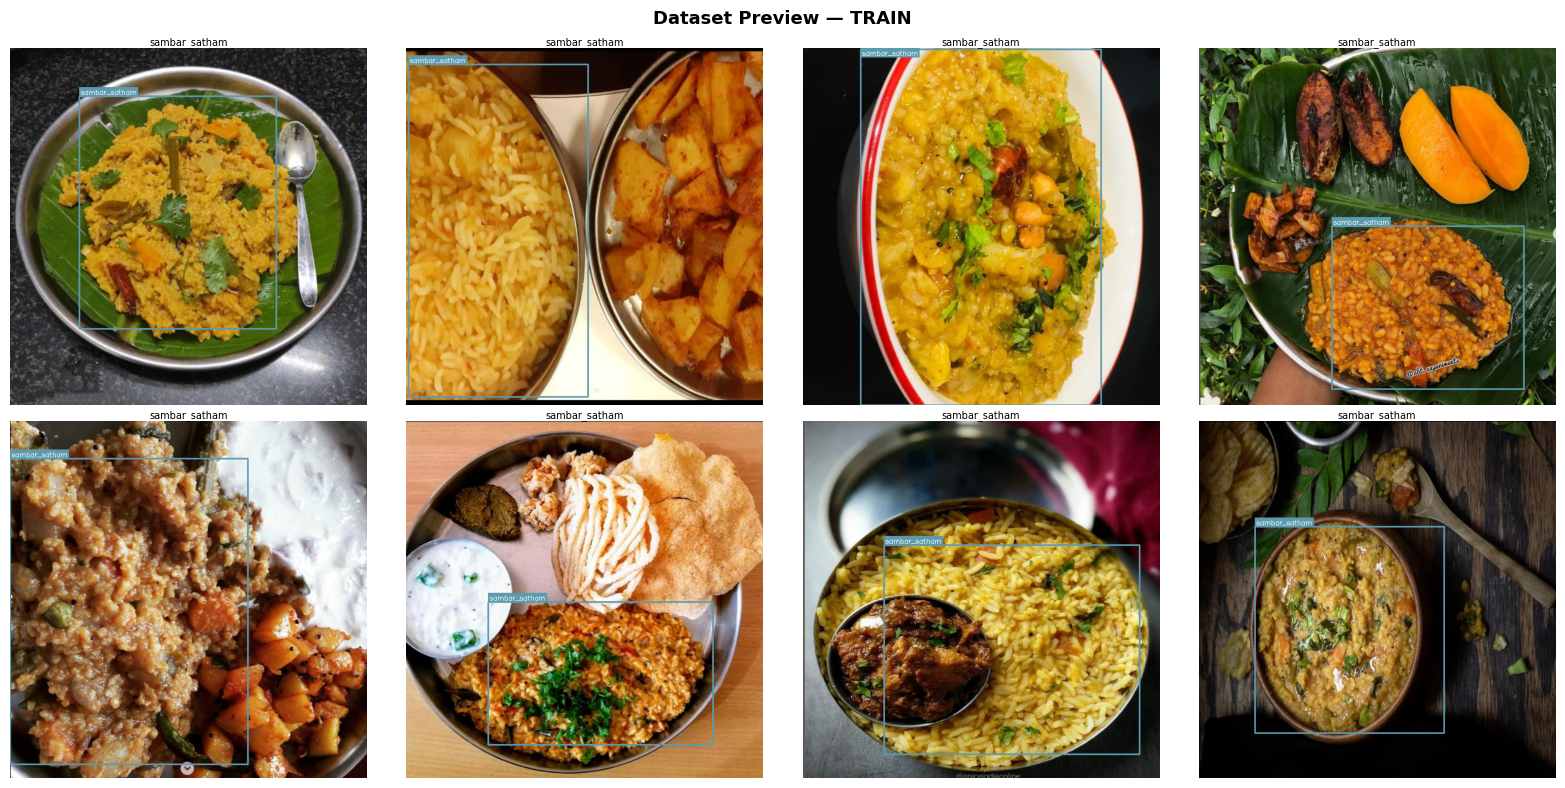

✅ Saved → /content/preview.png


In [ ]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path
import yaml

# ── Config ──────────────────────────────────────────────────
DATASET_PATH = Path("/content/nutrivision_merged")  # ← change if different
SPLIT        = "train"                               # train / valid / test
N_SAMPLES    = 8                                     # how many images to show
# ────────────────────────────────────────────────────────────

# Load class names
with open(DATASET_PATH / "data.yaml") as f:
    cfg = yaml.safe_load(f)
CLASS_NAMES = cfg['names']

# Random colors per class
random.seed(42)
COLORS = {i: tuple(random.randint(50, 230) for _ in range(3)) for i in range(len(CLASS_NAMES))}

img_dir = DATASET_PATH / SPLIT / "images"
lbl_dir = DATASET_PATH / SPLIT / "labels"

# Pick random label files
# Change this to any class name you want to inspect
FILTER_CLASS = "sambar_satham"

cid_filter = CLASS_NAMES.index(FILTER_CLASS)
filtered   = []
for lbl_file in lbl_dir.glob("*.txt"):
    with open(lbl_file) as f:
        ids = [int(float(l.split()[0])) for l in f if l.strip()]
    if cid_filter in ids:
        filtered.append(lbl_file)

print(f"Found {len(filtered)} images for '{FILTER_CLASS}'")

# Then replace `chosen` with:
chosen = random.sample(filtered, min(N_SAMPLES, len(filtered)))
# ... and re-run the plotting block above
cols = 4
rows = (len(chosen) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for ax in axes:
    ax.axis('off')

for idx, lbl_file in enumerate(chosen):
    ax = axes[idx]

    # Find matching image
    img_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        p = img_dir / (lbl_file.stem + ext)
        if p.exists():
            img_path = p
            break

    if img_path is None:
        ax.set_title("No image found", fontsize=8)
        continue

    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Draw boxes
    seen_classes = []
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            cid = int(float(parts[0]))
            cx, cy, bw, bh = map(float, parts[1:5])

            x1 = max(0, int((cx - bw/2) * w))
            y1 = max(0, int((cy - bh/2) * h))
            x2 = min(w, int((cx + bw/2) * w))
            y2 = min(h, int((cy + bh/2) * h))

            color = COLORS.get(cid, (0, 255, 0))
            name  = CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else str(cid)

            # Box
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

            # Label pill
            (tw, th), _ = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
            cv2.rectangle(img, (x1, max(y1-16, 0)), (x1+tw+4, max(y1, 16)), color, -1)
            cv2.putText(img, name, (x1+2, max(y1-3, 13)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

            if name not in seen_classes:
                seen_classes.append(name)

    ax.imshow(img)
    ax.set_title(", ".join(seen_classes), fontsize=7, pad=3)

plt.suptitle(f"Dataset Preview — {SPLIT.upper()}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/preview.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Saved → /content/preview.png")

In [ ]:
import os
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict, Counter
import random
import warnings
warnings.filterwarnings('ignore')

MERGED = Path("/content/nutrivision_merged")
SPLITS = ['train', 'valid', 'test']

# Load class names
with open(MERGED / 'data.yaml') as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg['names']
NC = cfg['nc']

print(f"✅ Dataset loaded")
print(f"   Classes : {NC}")
print(f"   Path    : {MERGED}")

✅ Dataset loaded
   Classes : 120
   Path    : /content/nutrivision_merged


In [ ]:
split_stats = {}

for split in SPLITS:
    img_dir = MERGED / split / 'images'
    lbl_dir = MERGED / split / 'labels'

    imgs = list(img_dir.glob("*.*"))
    lbls = list(lbl_dir.glob("*.txt"))

    # Count empty label files (background/unannotated images)
    empty = sum(1 for l in lbls if l.stat().st_size == 0)

    split_stats[split] = {
        'images' : len(imgs),
        'labels' : len(lbls),
        'empty'  : empty,
        'annotated': len(lbls) - empty
    }

print(f"\n{'Split':8s} {'Images':>8} {'Labels':>8} {'Annotated':>10} {'Empty':>8}")
print("─" * 48)
for split, s in split_stats.items():
    print(f"{split:8s} {s['images']:>8} {s['labels']:>8} {s['annotated']:>10} {s['empty']:>8}")

total_imgs = sum(s['images'] for s in split_stats.values())
print(f"\n  Total images : {total_imgs}")


Split      Images   Labels  Annotated    Empty
────────────────────────────────────────────────
train       34905    34905      34879       26
valid        2405     2405       2403        2
test         1875     1875       1873        2

  Total images : 39185


In [ ]:
# class_id → count of annotations per split
class_counts = {split: Counter() for split in SPLITS}
class_image_counts = {split: defaultdict(set) for split in SPLITS}

for split in SPLITS:
    lbl_dir = MERGED / split / 'labels'
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            cid = int(parts[0])
            class_counts[split][cid] += 1
            class_image_counts[split][cid].add(lbl_file.stem)

# Combined across all splits
total_annotations = Counter()
total_images_per_class = defaultdict(set)
for split in SPLITS:
    total_annotations += class_counts[split]
    for cid, stems in class_image_counts[split].items():
        total_images_per_class[cid].update(stems)

print(f"\n{'ID':>4}  {'Class Name':35s} {'Annotations':>12} {'Images':>8}")
print("─" * 65)
for cid in range(NC):
    name  = CLASS_NAMES[cid]
    annot = total_annotations.get(cid, 0)
    imgs  = len(total_images_per_class.get(cid, set()))
    flag  = " ⚠️ " if annot < 50 else ""
    print(f"{cid:>4}  {name:35s} {annot:>12} {imgs:>8}{flag}")

print(f"\n  Total annotations : {sum(total_annotations.values())}")


  ID  Class Name                           Annotations   Images
─────────────────────────────────────────────────────────────────
   0  adhirasam                                    550       84
   1  aloo_gobi                                    506      499
   2  aloo_masala                                  482      473
   3  aloo_matar                                    53       48
   4  aloo_methi                                    51       50
   5  aloo_shimla_mirch                             50       48
   6  aloo_tikki                                   245       48
   7  anarsa                                       318       50
   8  appam                                        721      720
   9  appe                                         487       50
  10  baati                                         66       47
  11  bandar_laddu                                 401       44
  12  basundi                                       72       47
  13  beetroot_poriyal               

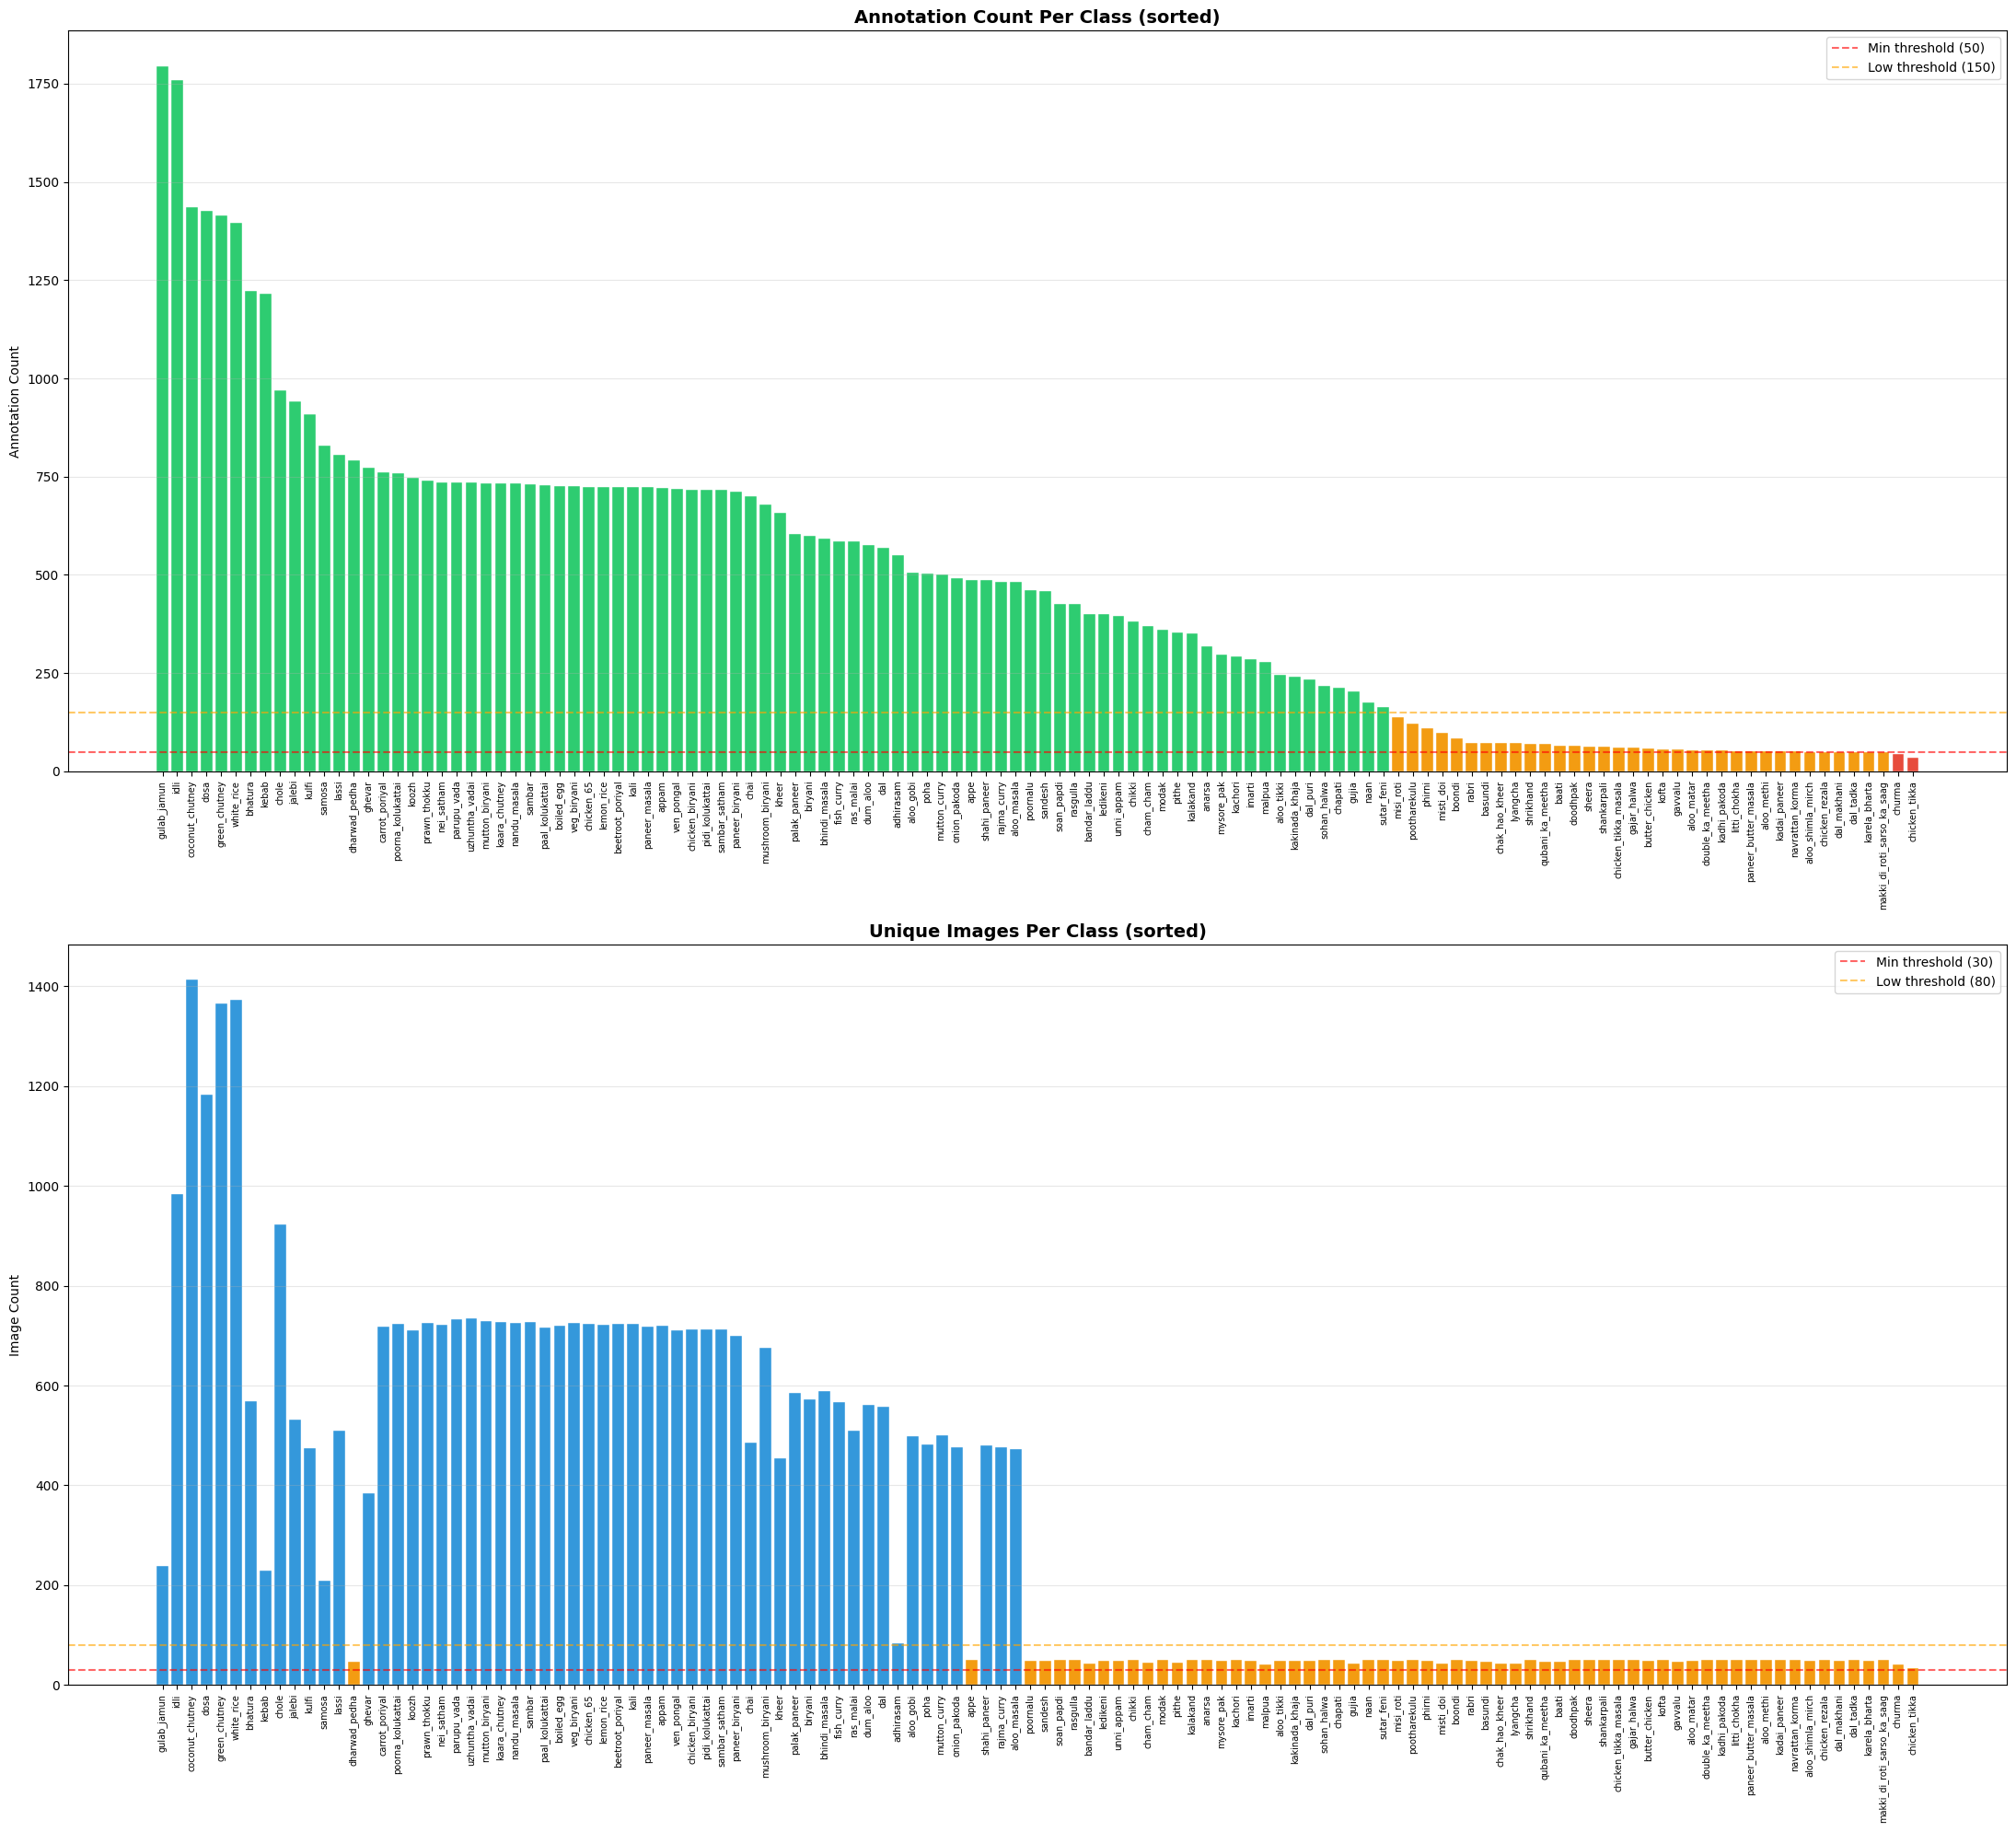

✅ Saved to /content/class_distribution.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(22, 20))

# ── Top: annotation count ──
sorted_ids   = sorted(range(NC), key=lambda x: total_annotations.get(x, 0), reverse=True)
sorted_names = [CLASS_NAMES[i] for i in sorted_ids]
sorted_vals  = [total_annotations.get(i, 0) for i in sorted_ids]

colors = ['#e74c3c' if v < 50 else '#f39c12' if v < 150 else '#2ecc71' for v in sorted_vals]

axes[0].bar(range(NC), sorted_vals, color=colors, edgecolor='white', linewidth=0.3)
axes[0].set_xticks(range(NC))
axes[0].set_xticklabels(sorted_names, rotation=90, fontsize=7)
axes[0].set_title('Annotation Count Per Class (sorted)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Annotation Count')
axes[0].axhline(y=50,  color='red',    linestyle='--', alpha=0.6, label='Min threshold (50)')
axes[0].axhline(y=150, color='orange', linestyle='--', alpha=0.6, label='Low threshold (150)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ── Bottom: image count ──
sorted_img_vals = [len(total_images_per_class.get(i, set())) for i in sorted_ids]
colors2 = ['#e74c3c' if v < 30 else '#f39c12' if v < 80 else '#3498db' for v in sorted_img_vals]

axes[1].bar(range(NC), sorted_img_vals, color=colors2, edgecolor='white', linewidth=0.3)
axes[1].set_xticks(range(NC))
axes[1].set_xticklabels(sorted_names, rotation=90, fontsize=7)
axes[1].set_title('Unique Images Per Class (sorted)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Image Count')
axes[1].axhline(y=30, color='red',    linestyle='--', alpha=0.6, label='Min threshold (30)')
axes[1].axhline(y=80, color='orange', linestyle='--', alpha=0.6, label='Low threshold (80)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to /content/class_distribution.png")

In [ ]:
print(f"\n{'Class Name':35s} {'Train':>8} {'Valid':>8} {'Test':>8} {'Total':>8}")
print("─" * 65)

for cid in sorted_ids:  # sorted by total count (descending)
    name = CLASS_NAMES[cid]
    tr = class_counts['train'].get(cid, 0)
    va = class_counts['valid'].get(cid, 0)
    te = class_counts['test'].get(cid, 0)
    to = tr + va + te
    flag = " ⚠️ " if to < 50 else ""
    print(f"{name:35s} {tr:>8} {va:>8} {te:>8} {to:>8}{flag}")


Class Name                             Train    Valid     Test    Total
─────────────────────────────────────────────────────────────────
gulab_jamun                             1560      124      111     1795
idli                                    1572      117       71     1760
coconut_chutney                         1284       88       63     1435
dosa                                    1262      105       59     1426
green_chutney                           1256       95       63     1414
white_rice                              1246       96       55     1397
bhatura                                 1075       96       52     1223
kebab                                   1074       89       52     1215
chole                                    846       77       47      970
jalebi                                   773      106       63      942
kulfi                                    789       69       51      909
samosa                                   726       60       43      8

In [ ]:
DROP_THRESHOLD = 50   # ← adjust as needed

classes_to_drop   = []
classes_to_review = []
classes_ok        = []

for cid in range(NC):
    count = total_annotations.get(cid, 0)
    name  = CLASS_NAMES[cid]
    if count == 0:
        classes_to_drop.append((cid, name, count))
    elif count < DROP_THRESHOLD:
        classes_to_drop.append((cid, name, count))
    elif count < 150:
        classes_to_review.append((cid, name, count))
    else:
        classes_ok.append((cid, name, count))

print(f"🔴 DROP  ({len(classes_to_drop)} classes, <{DROP_THRESHOLD} annotations):")
for cid, name, count in sorted(classes_to_drop, key=lambda x: x[2]):
    print(f"   {cid:3d}: {name:35s} → {count} annotations")

print(f"\n🟡 REVIEW ({len(classes_to_review)} classes, 50–150 annotations):")
for cid, name, count in sorted(classes_to_review, key=lambda x: x[2]):
    print(f"   {cid:3d}: {name:35s} → {count} annotations")

print(f"\n✅ OK     ({len(classes_ok)} classes, 150+ annotations)")
print(f"\n   After dropping → {NC - len(classes_to_drop)} classes remain")

🔴 DROP  (2 classes, <50 annotations):
    28: chicken_tikka                       → 35 annotations
    32: churma                              → 44 annotations

🟡 REVIEW (34 classes, 50–150 annotations):
     5: aloo_shimla_mirch                   → 50 annotations
    27: chicken_rezala                      → 50 annotations
    35: dal_makhani                         → 50 annotations
    37: dal_tadka                           → 50 annotations
    60: karela_bharta                       → 50 annotations
    71: makki_di_roti_sarso_ka_saag         → 50 annotations
     4: aloo_methi                          → 51 annotations
    55: kadai_paneer                        → 51 annotations
    82: navrattan_korma                     → 51 annotations
    69: litti_chokha                        → 52 annotations
    88: paneer_butter_masala                → 52 annotations
     3: aloo_matar                          → 53 annotations
    41: double_ka_meetha                    → 53 annotations
   

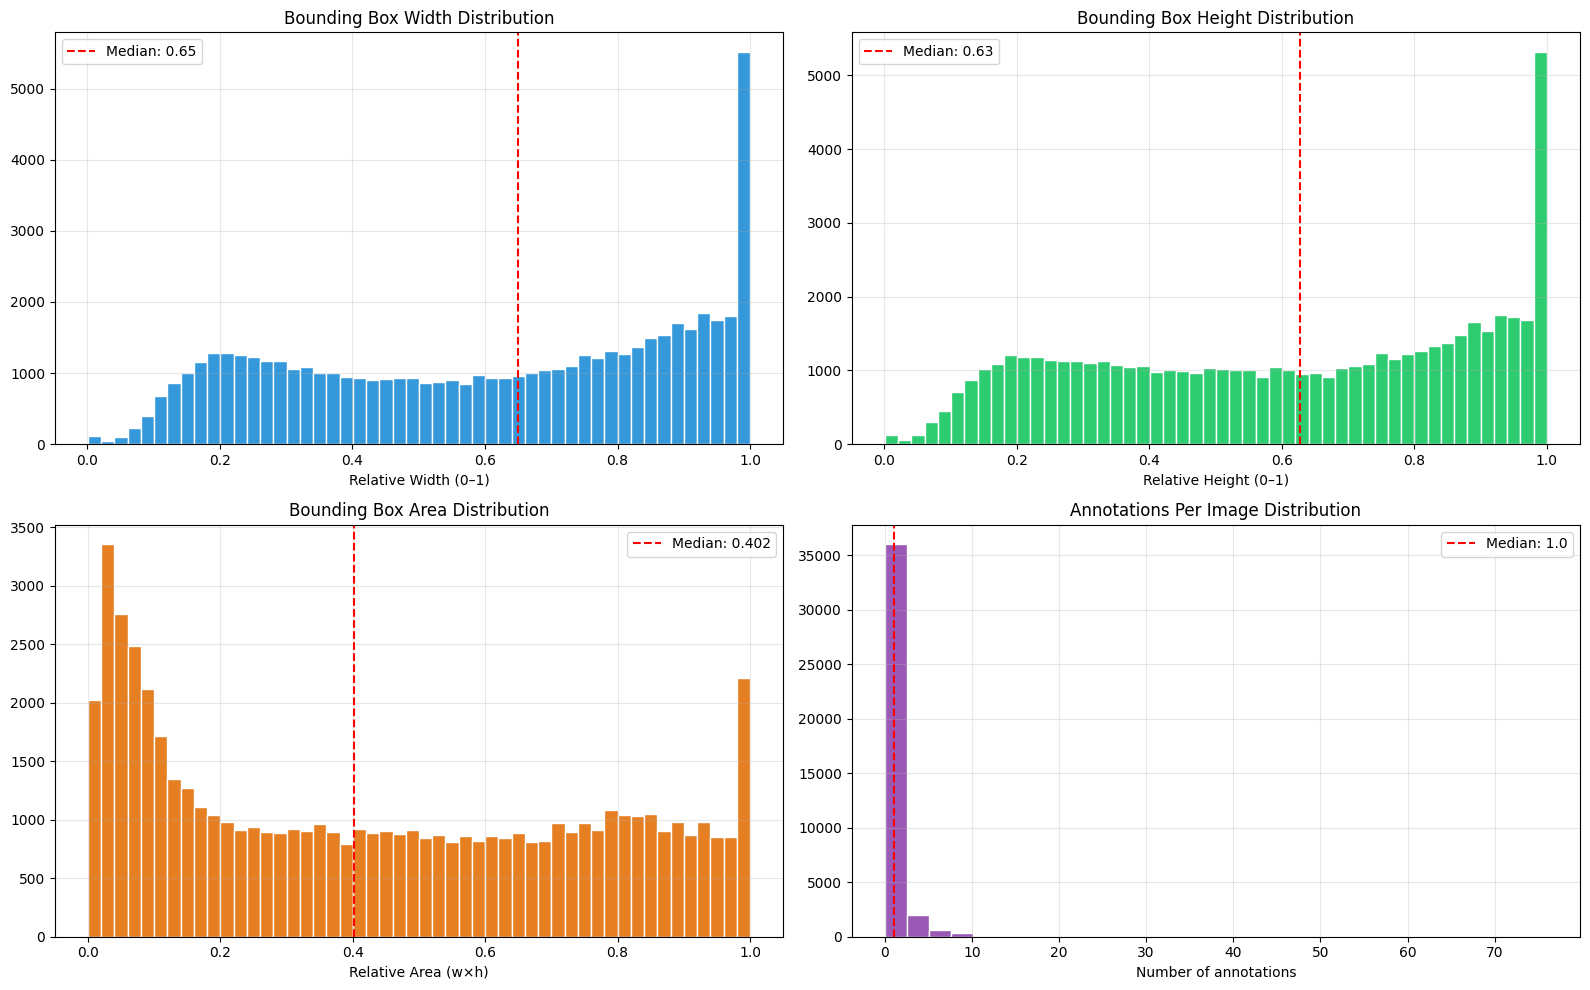


📊 BBox Stats:
   Width  — min: 0.001  max: 1.000  median: 0.650
   Height — min: 0.001  max: 1.000  median: 0.627
   Area   — min: 0.0000  max: 1.0000  median: 0.4023
   Annotations/image — max: 76  median: 1.0


In [ ]:
widths, heights, areas, aspect_ratios = [], [], [], []
annotations_per_image = []

for split in SPLITS:
    lbl_dir = MERGED / split / 'labels'
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            lines = [l.strip() for l in f if l.strip()]
        annotations_per_image.append(len(lines))
        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue
            w, h = float(parts[3]), float(parts[4])
            widths.append(w)
            heights.append(h)
            areas.append(w * h)
            aspect_ratios.append(w / h if h > 0 else 0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].hist(widths,  bins=50, color='#3498db', edgecolor='white')
axes[0,0].set_title('Bounding Box Width Distribution')
axes[0,0].set_xlabel('Relative Width (0–1)')
axes[0,0].axvline(np.median(widths), color='red', linestyle='--', label=f'Median: {np.median(widths):.2f}')
axes[0,0].legend()

axes[0,1].hist(heights, bins=50, color='#2ecc71', edgecolor='white')
axes[0,1].set_title('Bounding Box Height Distribution')
axes[0,1].set_xlabel('Relative Height (0–1)')
axes[0,1].axvline(np.median(heights), color='red', linestyle='--', label=f'Median: {np.median(heights):.2f}')
axes[0,1].legend()

axes[1,0].hist(areas,   bins=50, color='#e67e22', edgecolor='white')
axes[1,0].set_title('Bounding Box Area Distribution')
axes[1,0].set_xlabel('Relative Area (w×h)')
axes[1,0].axvline(np.median(areas), color='red', linestyle='--', label=f'Median: {np.median(areas):.3f}')
axes[1,0].legend()

axes[1,1].hist(annotations_per_image, bins=30, color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Annotations Per Image Distribution')
axes[1,1].set_xlabel('Number of annotations')
axes[1,1].axvline(np.median(annotations_per_image), color='red', linestyle='--',
                  label=f'Median: {np.median(annotations_per_image):.1f}')
axes[1,1].legend()

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/bbox_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 BBox Stats:")
print(f"   Width  — min: {min(widths):.3f}  max: {max(widths):.3f}  median: {np.median(widths):.3f}")
print(f"   Height — min: {min(heights):.3f}  max: {max(heights):.3f}  median: {np.median(heights):.3f}")
print(f"   Area   — min: {min(areas):.4f}  max: {max(areas):.4f}  median: {np.median(areas):.4f}")
print(f"   Annotations/image — max: {max(annotations_per_image)}  median: {np.median(annotations_per_image):.1f}")

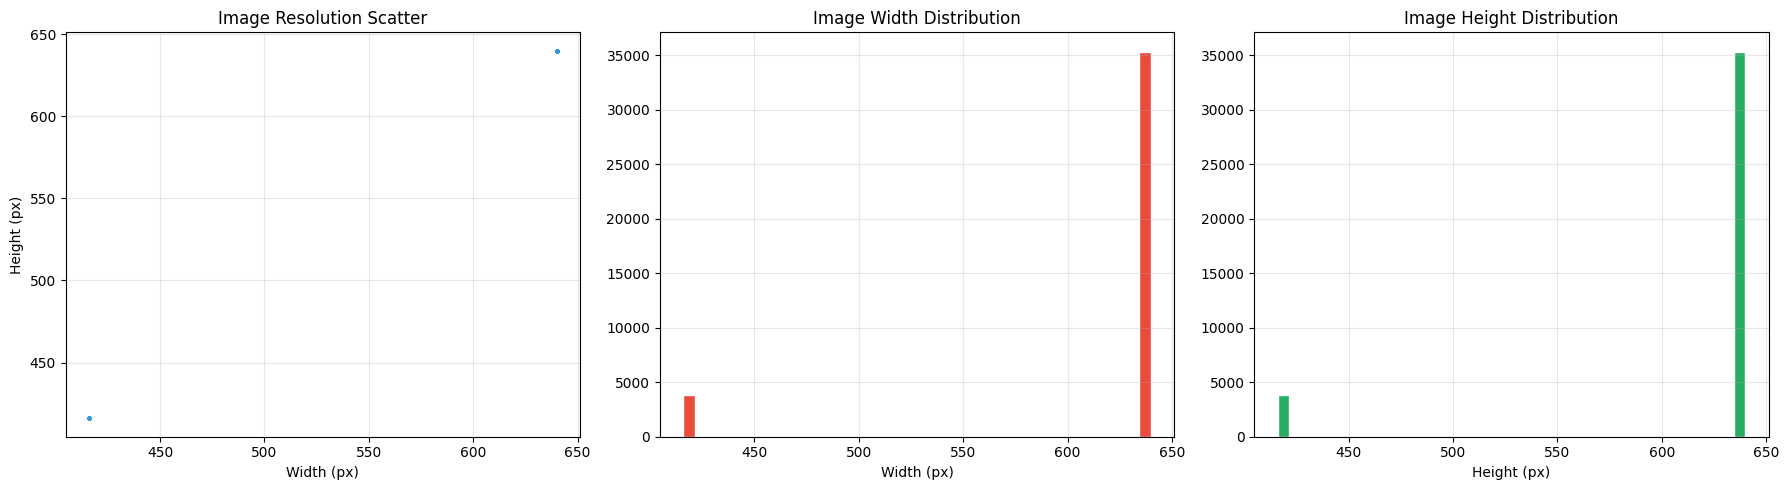


📐 Top 10 Resolutions:
     640 ×   640  →  35331 images
     416 ×   416  →   3854 images

   Min width  : 416px
   Max width  : 640px
   Min height : 416px
   Max height : 640px

✅ No corrupted images found


In [ ]:
resolutions = []
corrupted   = []

for split in SPLITS:
    img_dir = MERGED / split / 'images'
    for img_path in img_dir.glob("*.*"):
        img = cv2.imread(str(img_path))
        if img is None:
            corrupted.append(str(img_path))
            continue
        h, w = img.shape[:2]
        resolutions.append((w, h))

widths_res  = [r[0] for r in resolutions]
heights_res = [r[1] for r in resolutions]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(widths_res, heights_res, alpha=0.05, s=5, color='#3498db')
axes[0].set_title('Image Resolution Scatter')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')

axes[1].hist(widths_res,  bins=40, color='#e74c3c', edgecolor='white')
axes[1].set_title('Image Width Distribution')
axes[1].set_xlabel('Width (px)')

axes[2].hist(heights_res, bins=40, color='#27ae60', edgecolor='white')
axes[2].set_title('Image Height Distribution')
axes[2].set_xlabel('Height (px)')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/resolution_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

from collections import Counter
res_counter = Counter(resolutions)
print(f"\n📐 Top 10 Resolutions:")
for res, count in res_counter.most_common(10):
    print(f"   {res[0]:5d} × {res[1]:5d}  →  {count:5d} images")

print(f"\n   Min width  : {min(widths_res)}px")
print(f"   Max width  : {max(widths_res)}px")
print(f"   Min height : {min(heights_res)}px")
print(f"   Max height : {max(heights_res)}px")

if corrupted:
    print(f"\n❌ {len(corrupted)} corrupted images found:")
    for c in corrupted[:10]:
        print(f"   {c}")
else:
    print(f"\n✅ No corrupted images found")

In [ ]:
# ── Step 1: Build image path lookup ONCE (not inside loop) ──
img_lookup = {}
for split in SPLITS:
    img_dir = MERGED / split / 'images'
    for img_path in img_dir.iterdir():
        img_lookup[img_path.stem] = img_path   # stem → full path

print(f"✅ Image lookup built: {len(img_lookup)} images")

# ── Step 2: Build class index efficiently ──
class_samples = defaultdict(set)   # use set to avoid duplicates
for split in SPLITS:
    lbl_dir = MERGED / split / 'labels'
    for lbl_file in lbl_dir.glob("*.txt"):
        stem = lbl_file.stem
        if stem not in img_lookup:
            continue
        with open(lbl_file) as f:
            lines = f.readlines()
        seen_classes = set()
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            cid = int(parts[0])
            if cid not in seen_classes:
                class_samples[cid].add((img_lookup[stem], lbl_file))
                seen_classes.add(cid)

# Convert sets to lists
class_samples = {k: list(v) for k, v in class_samples.items()}
print(f"✅ Class index built: {len(class_samples)} classes with samples")

✅ Image lookup built: 39185 images
✅ Class index built: 120 classes with samples


In [ ]:
# ── Step 3: Plot all classes in one big figure (no plt.show() per class) ──
SAMPLES_PER_CLASS = 4   # reduced from 5
COLS = SAMPLES_PER_CLASS
ROWS = NC               # one row per class

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3, ROWS * 3))

for row, cid in enumerate(range(NC)):
    samples = class_samples.get(cid, [])
    chosen  = random.sample(samples, min(SAMPLES_PER_CLASS, len(samples)))

    for col in range(COLS):
        ax = axes[row, col]
        ax.axis('off')

        if col >= len(chosen):
            # Label the class on the first empty column
            if col == 0:
                ax.text(0.5, 0.5, f"[{cid}]\n{CLASS_NAMES[cid]}\nNO SAMPLES",
                        ha='center', va='center', fontsize=7,
                        transform=ax.transAxes, color='red')
            continue

        img_path, lbl_path = chosen[col]
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw boxes
        h, w = img.shape[:2]
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                c   = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                color = (0, 255, 0) if c == cid else (255, 100, 0)
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        ax.imshow(img)

        # Class label only on first column
        if col == 0:
            ax.set_ylabel(f"[{cid}] {CLASS_NAMES[cid]}\n({len(samples)} imgs)",
                          fontsize=7, rotation=0, ha='right', va='center',
                          labelpad=60)

plt.suptitle("NutriVision — Sample Images Per Class", fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()

# Save ONCE as single file
output_path = '/content/all_class_samples.png'
plt.savefig(output_path, dpi=80, bbox_inches='tight')   # dpi=80 keeps file small
plt.show()
print(f"✅ Done! Saved to {output_path}")

In [ ]:
print("=" * 60)
print("        NUTRIVISION EDA SUMMARY")
print("=" * 60)

total_annot = sum(total_annotations.values())
avg_per_class = total_annot / NC

print(f"\n📁 DATASET")
for split, s in split_stats.items():
    print(f"   {split:6s} → {s['images']:5d} images  ({s['empty']} empty labels)")
print(f"   Total  → {sum(s['images'] for s in split_stats.values())} images")

print(f"\n📦 ANNOTATIONS")
print(f"   Total       : {total_annot:,}")
print(f"   Avg/class   : {avg_per_class:.0f}")
print(f"   Max/class   : {max(total_annotations.values()):,}  → {CLASS_NAMES[max(total_annotations, key=total_annotations.get)]}")
print(f"   Min/class   : {min(total_annotations.get(i,0) for i in range(NC))}  → {CLASS_NAMES[min(range(NC), key=lambda x: total_annotations.get(x,0))]}")

print(f"\n🏷️  CLASSES")
print(f"   Total classes     : {NC}")
print(f"   🔴 Drop (<50)     : {len(classes_to_drop)}")
print(f"   🟡 Review (50-150): {len(classes_to_review)}")
print(f"   ✅ OK (150+)      : {len(classes_ok)}")
print(f"   After drop        : {NC - len(classes_to_drop)} classes")

print(f"\n📐 IMAGE RESOLUTIONS")
print(f"   Unique resolutions : {len(res_counter)}")
print(f"   Most common        : {res_counter.most_common(1)[0]}")

print(f"\n📦 BOUNDING BOXES")
tiny = sum(1 for a in areas if a < 0.01)
large = sum(1 for a in areas if a > 0.5)
print(f"   Tiny boxes (<1% area)  : {tiny} ({100*tiny/len(areas):.1f}%)")
print(f"   Large boxes (>50% area): {large} ({100*large/len(areas):.1f}%)")
print(f"   Median bbox area       : {np.median(areas):.4f}")

print(f"\n⚠️  ISSUES TO FIX BEFORE TRAINING")
print(f"   1. Drop {len(classes_to_drop)} classes with <50 annotations")
print(f"   2. Review {len(classes_to_review)} classes with 50-150 annotations")
if corrupted:
    print(f"   3. Remove {len(corrupted)} corrupted images")
if tiny > 0:
    print(f"   4. Consider filtering {tiny} tiny bounding boxes")
print("=" * 60)


        NUTRIVISION EDA SUMMARY

📁 DATASET
   train  → 34905 images  (26 empty labels)
   valid  →  2405 images  (2 empty labels)
   test   →  1875 images  (2 empty labels)
   Total  → 39185 images

📦 ANNOTATIONS
   Total       : 56,830
   Avg/class   : 474
   Max/class   : 1,795  → gulab_jamun
   Min/class   : 35  → chicken_tikka

🏷️  CLASSES
   Total classes     : 120
   🔴 Drop (<50)     : 2
   🟡 Review (50-150): 34
   ✅ OK (150+)      : 84
   After drop        : 118 classes

📐 IMAGE RESOLUTIONS
   Unique resolutions : 2
   Most common        : ((640, 640), 35331)

📦 BOUNDING BOXES
   Tiny boxes (<1% area)  : 737 (1.3%)
   Large boxes (>50% area): 24016 (42.3%)
   Median bbox area       : 0.4023

⚠️  ISSUES TO FIX BEFORE TRAINING
   1. Drop 2 classes with <50 annotations
   2. Review 34 classes with 50-150 annotations
   4. Consider filtering 737 tiny bounding boxes


# cleaning

In [ ]:
import yaml
import shutil
from pathlib import Path
from collections import Counter

MERGED = Path("/content/nutrivision_merged")
SPLITS = ['train', 'valid', 'test']

with open(MERGED / 'data.yaml') as f:
    cfg = yaml.safe_load(f)
CLASS_NAMES = cfg['names']
NC = cfg['nc']

# ── Edit this list based on your decision above ──
CLASSES_TO_DROP = [
    'chicken_tikka',
    'churma',
    'gavvalu',
    'chak_hao_kheer',
    'lyangcha',
    'doodhpak',
    'qubani_ka_meetha',
    'shankarpali',
    'pootharekulu',
]

DROP_IDS = {CLASS_NAMES.index(c) for c in CLASSES_TO_DROP}

print(f"Dropping {len(DROP_IDS)} classes:")
for cid in sorted(DROP_IDS):
    print(f"  {cid:3d}: {CLASS_NAMES[cid]}")

Dropping 9 classes:
   22: chak_hao_kheer
   28: chicken_tikka
   32: churma
   39: doodhpak
   45: gavvalu
   70: lyangcha
   97: pootharekulu
   99: qubani_ka_meetha
  109: shankarpali


In [ ]:
removed_annotations = Counter()
affected_files = 0

for split in SPLITS:
    lbl_dir = MERGED / split / 'labels'
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            lines = f.readlines()

        kept    = []
        removed = []
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            cid = int(float(parts[0]))
            if cid in DROP_IDS:
                removed_annotations[CLASS_NAMES[cid]] += 1
            else:
                kept.append(line)

        if len(kept) != len([l for l in lines if l.strip()]):
            affected_files += 1
            with open(lbl_file, 'w') as f:
                f.writelines(kept)

print(f"✅ Removed annotations:")
for cls, count in removed_annotations.items():
    print(f"   {cls:35s} → {count} annotations removed")
print(f"\n   Affected files: {affected_files}")

✅ Removed annotations:
   shankarpali                         → 62 annotations removed
   doodhpak                            → 65 annotations removed
   pootharekulu                        → 121 annotations removed
   churma                              → 44 annotations removed
   qubani_ka_meetha                    → 69 annotations removed
   chicken_tikka                       → 35 annotations removed
   chak_hao_kheer                      → 72 annotations removed
   lyangcha                            → 72 annotations removed
   gavvalu                             → 55 annotations removed

   Affected files: 405


In [ ]:
deleted_imgs   = 0
deleted_labels = 0

for split in SPLITS:
    img_dir = MERGED / split / 'images'
    lbl_dir = MERGED / split / 'labels'

    for lbl_file in lbl_dir.glob("*.txt"):
        content = lbl_file.read_text().strip()
        if content == "":
            lbl_file.unlink()
            deleted_labels += 1
            for ext in ['.jpg', '.jpeg', '.png']:
                img_file = img_dir / (lbl_file.stem + ext)
                if img_file.exists():
                    img_file.unlink()
                    deleted_imgs += 1
                    break

print(f"✅ Deleted {deleted_labels} empty label files")
print(f"✅ Deleted {deleted_imgs} corresponding images")

✅ Deleted 395 empty label files
✅ Deleted 395 corresponding images


In [ ]:
TINY_THRESHOLD = 0.001   # boxes covering <0.1% of image = noise

tiny_removed  = 0
files_cleaned = 0

for split in SPLITS:
    lbl_dir = MERGED / split / 'labels'
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            lines = f.readlines()

        kept    = []
        removed = 0
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            bw, bh = float(parts[3]), float(parts[4])
            if bw * bh < TINY_THRESHOLD:
                removed += 1
            else:
                kept.append(line)

        if removed > 0:
            tiny_removed  += removed
            files_cleaned += 1
            with open(lbl_file, 'w') as f:
                f.writelines(kept)

print(f"✅ Removed {tiny_removed} tiny boxes from {files_cleaned} files")

✅ Removed 124 tiny boxes from 113 files


In [ ]:
fixed_files = 0
fixed_lines = 0

for split in SPLITS:
    lbl_dir = MERGED / split / 'labels'
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            lines = f.readlines()

        new_lines    = []
        file_changed = False
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            if '.' in parts[0]:
                parts[0]     = str(int(float(parts[0])))
                file_changed = True
                fixed_lines += 1
            new_lines.append(" ".join(parts) + "\n")

        if file_changed:
            with open(lbl_file, 'w') as f:
                f.writelines(new_lines)
            fixed_files += 1

print(f"✅ Fixed {fixed_lines} lines in {fixed_files} files")

✅ Fixed 0 lines in 0 files


In [ ]:
new_class_names = [n for n in CLASS_NAMES if n not in CLASSES_TO_DROP]

old_to_new = {}
new_id = 0
for old_id, name in enumerate(CLASS_NAMES):
    if name not in CLASSES_TO_DROP:
        old_to_new[old_id] = new_id
        new_id += 1

print(f"Old classes : {len(CLASS_NAMES)}")
print(f"New classes : {len(new_class_names)}")

remapped_files = 0
for split in SPLITS:
    lbl_dir = MERGED / split / 'labels'
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            old_id = int(float(parts[0]))
            if old_id not in old_to_new:
                continue
            new_lines.append(
                f"{old_to_new[old_id]} " + " ".join(parts[1:]) + "\n"
            )

        with open(lbl_file, 'w') as f:
            f.writelines(new_lines)
        remapped_files += 1

print(f"✅ Remapped {remapped_files} label files")

Old classes : 120
New classes : 111
✅ Remapped 38790 label files


In [ ]:
import cv2

resized = 0
failed  = 0

for split in SPLITS:
    img_dir = MERGED / split / 'images'
    for img_path in img_dir.iterdir():
        if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            failed += 1
            continue
        h, w = img.shape[:2]
        if w == 416 and h == 416:
            img_resized = cv2.resize(img, (640, 640),
                                     interpolation=cv2.INTER_LINEAR)
            cv2.imwrite(str(img_path), img_resized)
            resized += 1

print(f"✅ Resized {resized} images from 416×416 → 640×640")
if failed:
    print(f"⚠️  Failed to read {failed} images")

✅ Resized 3461 images from 416×416 → 640×640


In [ ]:
# Write new yaml
final_yaml = {
    'path'  : str(MERGED),
    'train' : 'train/images',
    'val'   : 'valid/images',
    'test'  : 'test/images',
    'nc'    : len(new_class_names),
    'names' : new_class_names
}
with open(MERGED / 'data.yaml', 'w') as f:
    yaml.dump(final_yaml, f, default_flow_style=False, allow_unicode=True)

# Final count
final_counts = Counter()
for split in SPLITS:
    lbl_dir = MERGED / split / 'labels'
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    final_counts[int(float(parts[0]))] += 1

total_imgs = sum(
    len(list((MERGED / s / 'images').iterdir()))
    for s in SPLITS
)

print("=" * 55)
print("      CLEAN DATASET — READY FOR BALANCING")
print("=" * 55)
for split in SPLITS:
    imgs = len(list((MERGED / split / 'images').iterdir()))
    lbls = len(list((MERGED / split / 'labels').iterdir()))
    match = "✅" if imgs == lbls else "❌"
    print(f"  {split:6s} → {imgs:5d} images  {lbls:5d} labels  {match}")

print(f"\n  Total images      : {total_imgs:,}")
print(f"  Total annotations : {sum(final_counts.values()):,}")
print(f"  Classes in yaml   : {len(new_class_names)}")
print(f"  Classes in labels : {len(final_counts)}")
print(f"  Max class ID      : {max(final_counts.keys())}  (should be {len(new_class_names)-1})")
print(f"  Min annotations   : {min(final_counts.values())} → {new_class_names[min(final_counts, key=final_counts.get)]}")
print(f"  Max annotations   : {max(final_counts.values())} → {new_class_names[max(final_counts, key=final_counts.get)]}")

if max(final_counts.keys()) == len(new_class_names) - 1:
    print("\n  ✅ Dataset is clean — proceed to class balancing")
else:
    print("\n  ❌ ID mismatch — recheck step 6")
print("=" * 55)


      CLEAN DATASET — READY FOR BALANCING
  train  → 34587 images  34587 labels  ✅
  valid  →  2367 images   2367 labels  ✅
  test   →  1836 images   1836 labels  ✅

  Total images      : 38,790
  Total annotations : 56,111
  Classes in yaml   : 111
  Classes in labels : 111
  Max class ID      : 110  (should be 110)
  Min annotations   : 50 → makki_di_roti_sarso_ka_saag
  Max annotations   : 1795 → gulab_jamun

  ✅ Dataset is clean — proceed to class balancing


In [ ]:
import yaml
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

MERGED = Path("/content/nutrivision_merged")
SPLITS = ['train', 'valid', 'test']

with open(MERGED / 'data.yaml') as f:
    cfg = yaml.safe_load(f)
CLASS_NAMES = cfg['names']
NC          = cfg['nc']

# Count unique IMAGES per class (not annotations)
class_image_set   = defaultdict(set)   # class → set of image stems
image_class_map   = defaultdict(set)   # image stem → set of class ids
class_annot_count = Counter()          # class → total annotation count

for split in SPLITS:
    lbl_dir = MERGED / split / 'labels'
    for lbl_file in lbl_dir.glob("*.txt"):
        stem = lbl_file.stem
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cid = int(float(parts[0]))
                class_image_set[cid].add(f"{split}/{stem}")
                image_class_map[f"{split}/{stem}"].add(cid)
                class_annot_count[cid] += 1

# Summary per class
print(f"\n{'ID':>4}  {'Class Name':35s} {'Images':>8} {'Annots':>8} {'Avg/img':>8} {'Multi?':>8}")
print("─" * 75)
for cid in range(NC):
    name   = CLASS_NAMES[cid]
    imgs   = len(class_image_set[cid])
    annots = class_annot_count[cid]
    avg    = annots / imgs if imgs > 0 else 0
    multi  = "⚠️ YES" if avg > 2.0 else "no"
    print(f"{cid:>4}  {name:35s} {imgs:>8} {annots:>8} {avg:>8.1f} {multi:>8}")

print(f"\nTotal unique images : {len(image_class_map)}")


  ID  Class Name                            Images   Annots  Avg/img   Multi?
───────────────────────────────────────────────────────────────────────────
   0  adhirasam                                 84      550      6.5   ⚠️ YES
   1  aloo_gobi                                499      506      1.0       no
   2  aloo_masala                              473      482      1.0       no
   3  aloo_matar                                48       53      1.1       no
   4  aloo_methi                                50       51      1.0       no
   5  aloo_shimla_mirch                         48       50      1.0       no
   6  aloo_tikki                                48      245      5.1   ⚠️ YES
   7  anarsa                                    50      318      6.4   ⚠️ YES
   8  appam                                    720      720      1.0       no
   9  appe                                      50      487      9.7   ⚠️ YES
  10  baati                                     47       66      

In [ ]:
# How many images contain more than 1 class?
single_class_imgs = 0
multi_class_imgs  = 0
class_combo_count = Counter()

for stem, classes in image_class_map.items():
    if len(classes) == 1:
        single_class_imgs += 1
    else:
        multi_class_imgs += 1
        class_combo_count[len(classes)] += 1

print(f"Single-class images : {single_class_imgs:,}")
print(f"Multi-class images  : {multi_class_imgs:,}")
print(f"\nImages with N classes:")
for n, count in sorted(class_combo_count.items()):
    print(f"  {n} classes → {count:,} images")

Single-class images : 37,579
Multi-class images  : 1,207

Images with N classes:
  2 classes → 1,151 images
  3 classes → 49 images
  4 classes → 7 images


In [ ]:
import random
import yaml
from pathlib import Path
from collections import defaultdict, Counter

random.seed(42)

MERGED  = Path("/content/nutrivision_merged")
SPLITS  = ['train', 'valid', 'test']

with open(MERGED / 'data.yaml') as f:
    cfg = yaml.safe_load(f)
CLASS_NAMES = cfg['names']
NC          = cfg['nc']

TARGET_MAX = 500   # cap per class in TRAIN only

# ── Build train index ──────────────────────────────────────
train_lbl_dir = MERGED / 'train' / 'labels'
train_img_dir = MERGED / 'train' / 'images'

# stem → set of class ids in that image
train_image_classes = defaultdict(set)
# class id → set of image stems containing it
train_class_images  = defaultdict(set)

for lbl_file in train_lbl_dir.glob("*.txt"):
    stem = lbl_file.stem
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cid = int(float(parts[0]))
                train_image_classes[stem].add(cid)
                train_class_images[cid].add(stem)

print(f"{'Class':35s} {'Before':>8} {'Removed':>8} {'After':>8}")
print("─" * 62)

total_deleted = 0

for cid in range(NC):
    stems   = list(train_class_images[cid])
    current = len(stems)

    if current <= TARGET_MAX:
        continue

    n_remove = current - TARGET_MAX

    # Sort: remove single-class images first (safest)
    single = [s for s in stems if len(train_image_classes[s]) == 1]
    multi  = [s for s in stems if len(train_image_classes[s]) > 1]

    to_remove = (single + multi)[:n_remove]
    actually_removed = 0

    for stem in to_remove:
        classes_in_img = train_image_classes[stem]

        # If multi-class image, skip if another class is already poor
        if len(classes_in_img) > 1:
            skip = any(
                len(train_class_images[c]) <= TARGET_MAX * 0.4
                for c in classes_in_img if c != cid
            )
            if skip:
                continue

        # Delete label
        lbl = train_lbl_dir / (stem + ".txt")
        if lbl.exists():
            lbl.unlink()

        # Delete image
        for ext in ['.jpg', '.jpeg', '.png']:
            img = train_img_dir / (stem + ext)
            if img.exists():
                img.unlink()
                break

        # Update tracking maps
        for c in list(classes_in_img):
            train_class_images[c].discard(stem)
        del train_image_classes[stem]

        actually_removed += 1

    total_deleted += actually_removed
    after = len(train_class_images[cid])
    print(f"  {CLASS_NAMES[cid]:35s} {current:>8} {actually_removed:>8} {after:>8}")

print(f"\n✅ Total images deleted from train : {total_deleted}")

Class                                 Before  Removed    After
──────────────────────────────────────────────────────────────
  appam                                    660      160      500
  beetroot_poriyal                         663      163      500
  bhindi_masala                            511       11      500
  boiled_egg                               659      159      500
  carrot_poriyal                           658      158      500
  chicken_65                               664      164      500
  chicken_biryani                          652      152      500
  chole                                    802      302      500
  coconut_chutney                         1269      769      500
  dosa                                    1064      564      500
  green_chutney                           1217      717      500
  idli                                     891      391      500
  kaara_chutney                            667      167      500
  kali                       

In [ ]:
import cv2
import albumentations as A
import numpy as np

# !pip install albumentations -q

TARGET_MIN = 150   # bring every class up to this many images

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.25,
        contrast_limit=0.25,
        p=0.7
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=25,
        val_shift_limit=20,
        p=0.5
    ),
    A.Rotate(limit=15, p=0.4),
    A.GaussNoise(var_limit=(5, 20), p=0.3),
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_visibility=0.3
))


def augment_and_save(img_path, lbl_path, out_img_dir, out_lbl_dir, tag):
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with open(lbl_path) as f:
        lines = [l.strip().split() for l in f if l.strip()]
    if not lines:
        return False

    bboxes       = [[float(x) for x in l[1:5]] for l in lines]
    # ── Fix: force int BEFORE passing to albumentations ──
    class_labels = [int(float(l[0])) for l in lines]

    try:
        result = transform(
            image=img,
            bboxes=bboxes,
            class_labels=class_labels
        )
    except Exception:
        return False

    if not result['bboxes']:
        return False

    new_stem = f"aug_{tag}_{img_path.stem}"
    out_img  = out_img_dir / (new_stem + '.jpg')
    out_lbl  = out_lbl_dir / (new_stem + '.txt')

    cv2.imwrite(str(out_img),
                cv2.cvtColor(result['image'], cv2.COLOR_RGB2BGR))

    with open(out_lbl, 'w') as f:
        for bbox, cid in zip(result['bboxes'], result['class_labels']):
            cx, cy, bw, bh = bbox
            # ── Fix: always write as int ──────────────────
            f.write(f"{int(cid)} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

    return True


# ── Rebuild index after undersampling ─────────────────────
img_lookup = {p.stem: p for p in train_img_dir.iterdir()}

train_class_files  = defaultdict(list)
train_class_count  = Counter()   # current image count per class

for lbl_file in train_lbl_dir.glob("*.txt"):
    if lbl_file.stem not in img_lookup:
        continue
    seen = set()
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cid = int(float(parts[0]))
                if cid not in seen:
                    train_class_files[cid].append(
                        (img_lookup[lbl_file.stem], lbl_file)
                    )
                    seen.add(cid)
    for cid in seen:
        train_class_count[cid] += 1

# ── Augment ───────────────────────────────────────────────
print(f"{'Class':35s} {'Before':>8} {'Added':>8} {'After':>8}")
print("─" * 62)

total_generated = 0

for cid in range(NC):
    current = train_class_count[cid]

    if current >= TARGET_MIN or current == 0:
        continue

    needed  = TARGET_MIN - current
    samples = train_class_files.get(cid, [])
    if not samples:
        print(f"  ⚠️  {CLASS_NAMES[cid]:35s} — no source images found")
        continue

    generated = 0
    attempt   = 0

    while generated < needed and attempt < needed * 8:
        img_path, lbl_path = random.choice(samples)
        success = augment_and_save(
            img_path, lbl_path,
            train_img_dir, train_lbl_dir,
            f"c{cid}_{attempt}"
        )
        if success:
            generated += 1
        attempt += 1

    total_generated += generated
    print(f"  {CLASS_NAMES[cid]:35s} {current:>8} {generated:>8} {current+generated:>8}")

print(f"\n✅ Total new images generated : {total_generated}")

# ── Quick verify float IDs didn't sneak in ────────────────
float_found = 0
for lbl_file in train_lbl_dir.glob("aug_*.txt"):
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts and '.' in parts[0]:
                float_found += 1

if float_found == 0:
    print("✅ Zero float class IDs in augmented files")
else:
    print(f"❌ {float_found} float IDs found — run the float fix cell")

/tmp/ipykernel_397/4241018831.py:23: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.3),


Class                                 Before    Added    After
──────────────────────────────────────────────────────────────
  adhirasam                                 70       80      150
  aloo_matar                                40      110      150
  aloo_methi                                40      110      150
  aloo_shimla_mirch                         38      112      150
  aloo_tikki                                39      111      150
  anarsa                                    40      110      150
  appe                                      40      110      150
  baati                                     37      113      150
  bandar_laddu                              36      114      150
  basundi                                   39      111      150
  boondi                                    40      110      150
  butter_chicken                            39      111      150
  cham_cham                                 39      111      150
  chapati                    

In [ ]:
# Quick distribution check
final_counts = Counter()
for lbl_file in train_lbl_dir.glob("*.txt"):
    seen = set()
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                seen.add(int(float(parts[0])))
    for cid in seen:
        final_counts[cid] += 1

print(f"\n{'Metric':<20} {'Value':>10}")
print("─" * 32)
print(f"{'Min images/class':<20} {min(final_counts.values()):>10}")
print(f"{'Max images/class':<20} {max(final_counts.values()):>10}")
print(f"{'Balance ratio':<20} {max(final_counts.values())/min(final_counts.values()):>10.1f}x")
print(f"{'Total train images':<20} {len(list(train_img_dir.iterdir())):>10,}")

under = [CLASS_NAMES[i] for i,v in final_counts.items() if v < TARGET_MIN]
over  = [CLASS_NAMES[i] for i,v in final_counts.items() if v > TARGET_MAX]
print(f"\n  Still under {TARGET_MIN}: {len(under)} classes {under if under else '✅ none'}")
print(f"  Still over  {TARGET_MAX}: {len(over)} classes {over if over else '✅ none'}")


Metric                    Value
────────────────────────────────
Min images/class            150
Max images/class            586
Balance ratio               3.9x
Total train images       33,053

  Still under 150: 0 classes ✅ none
  Still over  500: 1 classes ['dal']


In [ ]:
import yaml
from pathlib import Path

MERGED = Path("/content/nutrivision_merged")

with open(MERGED / 'data.yaml') as f:
    cfg = yaml.safe_load(f)

print("data.yaml contents:")
print(f"  path  : {cfg['path']}")
print(f"  train : {cfg['train']}")
print(f"  val   : {cfg['val']}")
print(f"  test  : {cfg['test']}")
print(f"  nc    : {cfg['nc']}")
print(f"  names : {cfg['names'][:5]} ... {cfg['names'][-3:]}")

# Must match
assert cfg['nc'] == len(cfg['names']), "❌ nc doesn't match names count"
assert Path(cfg['path']).exists(),     "❌ path doesn't exist"
print("\n✅ data.yaml is valid")

data.yaml contents:
  path  : /content/nutrivision_merged
  train : train/images
  val   : valid/images
  test  : test/images
  nc    : 111
  names : ['adhirasam', 'aloo_gobi', 'aloo_masala', 'aloo_matar', 'aloo_methi'] ... ['veg_biryani', 'ven_pongal', 'white_rice']

✅ data.yaml is valid


In [ ]:
splits = ['train', 'valid', 'test']
counts = {}
total  = 0

for split in splits:
    n = len(list((MERGED / split / 'images').iterdir()))
    counts[split] = n
    total += n

print("Split distribution:")
for split, n in counts.items():
    pct = 100 * n / total
    ok  = "✅" if (
        (split == 'train' and 70 <= pct <= 90) or
        (split == 'valid' and 5  <= pct <= 20) or
        (split == 'test'  and 5  <= pct <= 15)
    ) else "⚠️"
    print(f"  {split:6s} → {n:6,} images  ({pct:.1f}%)  {ok}")

print(f"\n  Total → {total:,} images")
print(f"\n  Ideal split: 80% train / 10% valid / 10% test")

Split distribution:
  train  → 33,053 images  (88.7%)  ✅
  valid  →  2,367 images  (6.4%)  ✅
  test   →  1,836 images  (4.9%)  ⚠️

  Total → 37,256 images

  Ideal split: 80% train / 10% valid / 10% test


In [ ]:
SPLITS = ['train', 'valid', 'test']

with open(MERGED / 'data.yaml') as f:
    cfg = yaml.safe_load(f)
NC = cfg['nc']

invalid_found = 0
float_found   = 0
empty_annot   = 0

for split in SPLITS:
    lbl_dir = MERGED / split / 'labels'
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            lines = [l.strip() for l in f if l.strip()]

        if not lines:
            empty_annot += 1
            continue

        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue

            # Float ID check
            if '.' in parts[0]:
                float_found += 1

            # Invalid ID check
            cid = int(float(parts[0]))
            if cid < 0 or cid >= NC:
                invalid_found += 1

print("Final label audit:")
print(f"  Invalid class IDs : {invalid_found}  {'✅' if invalid_found == 0 else '❌'}")
print(f"  Float class IDs   : {float_found}    {'✅' if float_found   == 0 else '❌'}")
print(f"  Empty label files : {empty_annot}   (background images — OK)")

if invalid_found == 0 and float_found == 0:
    print("\n  ✅ All labels are clean")
else:
    print("\n  ❌ Fix issues before training")


Final label audit:
  Invalid class IDs : 0  ✅
  Float class IDs   : 0    ✅
  Empty label files : 4   (background images — OK)

  ✅ All labels are clean


In [ ]:
import shutil
from pathlib import Path

shutil.make_archive('/content/nutrivision_final2', 'zip',
                    '/content', 'nutrivision_merged')

size = Path('/content/nutrivision_final2.zip').stat().st_size
print(f"✅ Saved → /content/nutrivision_final2.zip")
print(f"   Size  : {size / (1024*1024*1024):.2f} GB")

✅ Saved → /content/nutrivision_final2.zip
   Size  : 3.00 GB


In [ ]:
!rm -rf /content/nutrivision_merged.zip

In [ ]:
!cp /content/nutrivision_final2.zip /content/drive/MyDrive